# LightGBM Hyperparameter Tuning

**Module:** IT3051 - Fundamentals of Data Mining  
**Project:** Next-Year PM2.5 Air-Quality Risk Classification  
**Model:** LightGBM Classifier  
**Purpose:** Hyperparameter tuning and model optimization

This notebook:

- Loads the chronological train/validation/test datasets
- Reuses the project preprocessing pipeline
- Fits preprocessing only on the training data
- Performs systematic hyperparameter tuning for LightGBM
- Selects the best configuration using validation Macro F1
- Compares the tuned model with the LightGBM baseline
- Evaluates the tuned model on the validation set
- Keeps the test set untouched for final model evaluation

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from itertools import product

# Make this work when the notebook is run from the project's notebooks folder
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.preprocessing.preprocessing_pipeline import (
    TARGET_COLUMN,
    prepare_base_dataframe,
    prepare_features_and_target,
    build_preprocessor,
)

print("Imports loaded successfully.")
print("Project root:", project_root)

Imports loaded successfully.
Project root: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project


## 1. Load Chronological Train / Validation / Test Data

The datasets are loaded using the chronological split created during the data preparation stage.

- Training data: 1997–2012
- Validation data: 2013–2014
- Test data: 2015–2016

The test set will remain untouched during hyperparameter tuning.

In [2]:
# ============================================================
# 1. Load Chronological Train / Validation / Test Data
# ============================================================

data_dir = project_root / "data" / "processed"

train_path = data_dir / "train_data.csv"
val_path = data_dir / "validation_data.csv"
test_path = data_dir / "test_data.csv"

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Dataset shapes:")
print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)

Dataset shapes:
Train      : (13191, 38)
Validation : (1783, 38)
Test       : (1561, 38)


## 2. Confirm the Chronological Split

This check confirms that the chronological train, validation, and test datasets are separated by year.

* Training data: up to 2012
* Validation data: 2013–2014
* Test data: 2015–2016

The chronological split is maintained to prevent future information from being used during model training and hyperparameter tuning.


In [3]:
# ============================================================
# 2. Confirm the Chronological Split
# ============================================================

for name, dataset in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:
    print(
        f"{name}: {dataset['year'].min()} - {dataset['year'].max()} "
        f"({len(dataset)} rows)"
    )

Training: 1997 - 2012 (13191 rows)
Validation: 2013 - 2014 (1783 rows)
Test: 2015 - 2016 (1561 rows)


## 3. Apply Base Cleaning to Each Split

The same base preprocessing function used in the project preprocessing pipeline is applied to the training, validation, and test datasets.

Each split is processed separately using the same preprocessing logic.


In [4]:
# ============================================================
# 3. Apply Base Cleaning to Each Split
# ============================================================

train_prepared = prepare_base_dataframe(train_df)
validation_prepared = prepare_base_dataframe(val_df)
test_prepared = prepare_base_dataframe(test_df)

print("Base preprocessing completed.")
print("Training shape   :", train_prepared.shape)
print("Validation shape :", validation_prepared.shape)
print("Test shape       :", test_prepared.shape)

Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Basic dataframe validation passed.
No duplicate rows found.
No known direct future-target leakage columns detected.
Base preprocessing completed.
Training shape   : (13191, 38)
Validation shape : (1783, 38)
Test shape       : (1561, 38)


## 4. Separate Features and Target

The target variable is separated from the predictor variables using the project's preprocessing pipeline.

Identifier columns are excluded by the existing `prepare_features_and_target()` function.

The same feature-target separation is applied consistently to the training, validation, and test datasets.


In [5]:
# ============================================================
# 4. Separate Features and Target
# ============================================================

X_train, y_train = prepare_features_and_target(train_prepared)
X_val, y_val = prepare_features_and_target(validation_prepared)
X_test, y_test = prepare_features_and_target(test_prepared)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val  :", X_val.shape, "| y_val  :", y_val.shape)
print("X_test :", X_test.shape, "| y_test :", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

Feature matrix shape: (13191, 33)
Target shape: (13191,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
Feature matrix shape: (1783, 33)
Target shape: (1783,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
Feature matrix shape: (1561, 33)
Target shape: (1561,)
Excluded identifier columns: ['site_id', 'state_code', 'county_code', 'site_num']
X_train: (13191, 33) | y_train: (13191,)
X_val  : (1783, 33) | y_val  : (1783,)
X_test : (1561, 33) | y_test : (1561,)

Training target distribution:
pm25_risk_category_next_year
Moderate                          6849
Unhealthy for Sensitive Groups    5049
Unhealthy                         1203
Good                                52
Very Unhealthy                      38
Name: count, dtype: int64


## 5. Build and Fit the Preprocessor

The project preprocessing pipeline is fitted using the training features only.

The fitted transformer is then used to transform the validation and test features.

This prevents information leakage from future data during hyperparameter tuning.


In [6]:
# ============================================================
# 5. Build and Fit the Preprocessor
# ============================================================

preprocessor = build_preprocessor(X_train)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed.")
print("Processed training shape   :", X_train_processed.shape)
print("Processed validation shape :", X_val_processed.shape)
print("Processed test shape       :", X_test_processed.shape)

Numerical features: 29
Categorical features: 4
Preprocessing completed.
Processed training shape   : (13191, 2154)
Processed validation shape : (1783, 2154)
Processed test shape       : (1561, 2154)


## 6. Hyperparameter Search Space

A compact systematic grid is used to tune the most influential LightGBM hyperparameters.

The search evaluates:

* Number of boosting iterations (`n_estimators`)
* Learning rate (`learning_rate`)
* Number of leaves (`num_leaves`)
* Maximum tree depth (`max_depth`)
* Row subsampling (`subsample`)
* Feature subsampling (`colsample_bytree`)

The primary model selection metric is validation Macro F1 because the target classes are imbalanced.


In [7]:
# ============================================================
# 6. Define LightGBM Hyperparameter Search Space
# ============================================================

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [15, 31],
    "max_depth": [-1, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

total_combinations = (
    len(param_grid["n_estimators"])
    * len(param_grid["learning_rate"])
    * len(param_grid["num_leaves"])
    * len(param_grid["max_depth"])
    * len(param_grid["subsample"])
    * len(param_grid["colsample_bytree"])
)

print("Total parameter combinations:", total_combinations)
print("Primary selection metric: Validation Macro F1")

Total parameter combinations: 64
Primary selection metric: Validation Macro F1


## 7. Run Hyperparameter Tuning Experiments

Each LightGBM configuration is trained using the training data and evaluated on the chronological validation data.

Validation Macro F1 is used as the primary selection metric, while validation Accuracy is also recorded for comparison.

The test set is not used during hyperparameter selection.


In [8]:
# ============================================================
# 7. Run Hyperparameter Tuning Experiments
# ============================================================

tuning_results = []

for (
    n_estimators,
    learning_rate,
    num_leaves,
    max_depth,
    subsample,
    colsample_bytree
) in product(
    param_grid["n_estimators"],
    param_grid["learning_rate"],
    param_grid["num_leaves"],
    param_grid["max_depth"],
    param_grid["subsample"],
    param_grid["colsample_bytree"]
):

    model = LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        max_depth=max_depth,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42,
        verbosity=-1
    )

    model.fit(X_train_processed, y_train)

    y_val_pred = model.predict(X_val_processed)

    tuning_results.append({
        "n_estimators": n_estimators,
        "learning_rate": learning_rate,
        "num_leaves": num_leaves,
        "max_depth": max_depth,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "validation_accuracy": accuracy_score(
            y_val, y_val_pred
        ),
        "validation_macro_f1": f1_score(
            y_val,
            y_val_pred,
            average="macro",
            zero_division=0
        )
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    ["validation_macro_f1", "validation_accuracy"],
    ascending=False
).reset_index(drop=True)

print("Hyperparameter tuning completed.")
print("Configurations evaluated:", len(tuning_results_df))

tuning_results_df.head(10)

Hyperparameter tuning completed.
Configurations evaluated: 64


,n_estimators,learning_rate,num_leaves,max_depth,subsample,colsample_bytree,validation_accuracy,validation_macro_f1
0,200,0.05,31,5,0.8,1.0,0.765564,0.382495
1,200,0.05,31,5,1.0,1.0,0.765564,0.382495
2,200,0.05,15,-1,0.8,1.0,0.763881,0.375333
3,200,0.05,15,-1,1.0,1.0,0.763881,0.375333
4,200,0.10,15,-1,0.8,1.0,0.766125,0.352260
5,200,0.10,15,-1,1.0,1.0,0.766125,0.352260
6,200,0.05,31,-1,0.8,1.0,0.766125,0.326726
7,200,0.05,31,-1,1.0,1.0,0.766125,0.326726
8,200,0.05,31,-1,0.8,0.8,0.768368,0.325838
9,200,0.05,31,-1,1.0,0.8,0.768368,0.325838


## 8. Save Hyperparameter Tuning Results

All hyperparameter tuning results are saved as a CSV file.

This provides a record of every tested LightGBM configuration and its validation performance.


In [9]:
# ============================================================
# 8. Save Hyperparameter Tuning Results
# ============================================================

results_dir = project_root / "reports" / "model_results"
pictures_dir = project_root / "reports" / "pictures"

results_dir.mkdir(parents=True, exist_ok=True)
pictures_dir.mkdir(parents=True, exist_ok=True)

tuning_results_path = (
    results_dir / "lightgbm_tuning_all_results.csv"
)

tuning_results_df.to_csv(
    tuning_results_path,
    index=False
)

print("Saved:", tuning_results_path)

Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\lightgbm_tuning_all_results.csv


## 9. Select the Best Hyperparameters

The best LightGBM configuration is selected based on the highest validation Macro F1.

Validation Accuracy is used as the secondary criterion when two configurations have the same Macro F1.

In [10]:
# ============================================================
# 9. Select the Best Hyperparameters
# ============================================================

best_row = tuning_results_df.iloc[0]

best_params = {
    "n_estimators": int(best_row["n_estimators"]),
    "learning_rate": float(best_row["learning_rate"]),
    "num_leaves": int(best_row["num_leaves"]),
    "max_depth": int(best_row["max_depth"]),
    "subsample": float(best_row["subsample"]),
    "colsample_bytree": float(best_row["colsample_bytree"]),
}

print("Best parameters:")
print(best_params)

print(
    "\nBest validation Macro F1:",
    round(float(best_row["validation_macro_f1"]), 6)
)

print(
    "Corresponding validation Accuracy:",
    round(float(best_row["validation_accuracy"]), 6)
)

Best parameters:
{'n_estimators': 200, 'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 1.0}

Best validation Macro F1: 0.382495
Corresponding validation Accuracy: 0.765564


## 10. Train and Evaluate the Tuned LightGBM Model

The LightGBM classifier is retrained using the selected best hyperparameters.

The model is trained only on the training data and evaluated on the chronological validation data.

The test set remains untouched for final model evaluation.

In [11]:
# ============================================================
# 10. Train and Evaluate the Tuned LightGBM Model
# ============================================================

lgbm_tuned = LGBMClassifier(
    **best_params,
    random_state=42,
    verbosity=-1
)

lgbm_tuned.fit(
    X_train_processed,
    y_train
)

y_val_pred_tuned = lgbm_tuned.predict(
    X_val_processed
)

tuned_accuracy = accuracy_score(
    y_val,
    y_val_pred_tuned
)

tuned_macro_f1 = f1_score(
    y_val,
    y_val_pred_tuned,
    average="macro",
    zero_division=0
)

print(f"Tuned Validation Accuracy: {tuned_accuracy:.6f}")
print(f"Tuned Validation Macro F1: {tuned_macro_f1:.6f}")

Tuned Validation Accuracy: 0.765564
Tuned Validation Macro F1: 0.382495


## 11. Compare Baseline and Tuned Models

The tuned LightGBM model is compared with the baseline LightGBM model using the validation Accuracy and Macro F1 scores.

The comparison helps identify the effect of hyperparameter tuning on model performance.


In [12]:
# ============================================================
# 11. Compare Baseline and Tuned Models
# ============================================================

baseline_accuracy = 0.7644
baseline_macro_f1 = 0.3207

comparison_df = pd.DataFrame({
    "Model": [
        "LightGBM Baseline",
        "LightGBM Tuned"
    ],
    "Validation Accuracy": [
        baseline_accuracy,
        tuned_accuracy
    ],
    "Validation Macro F1": [
        baseline_macro_f1,
        tuned_macro_f1
    ]
})

comparison_df["Accuracy Change"] = (
    comparison_df["Validation Accuracy"] - baseline_accuracy
)

comparison_df["Macro F1 Change"] = (
    comparison_df["Validation Macro F1"] - baseline_macro_f1
)

comparison_df

,Model,Validation Accuracy,Validation Macro F1,Accuracy Change,Macro F1 Change
0,LightGBM Baseline,0.764400,0.320700,0.000000,0.000000
1,LightGBM Tuned,0.765564,0.382495,0.001164,0.061795


## 12. Save Baseline vs Tuned Comparison

The validation performance comparison between the baseline and tuned LightGBM models is saved as a CSV file.

This provides a reproducible record of the improvement obtained through hyperparameter tuning.


In [13]:
# ============================================================
# 12. Save Baseline vs Tuned Comparison
# ============================================================

comparison_path = (
    results_dir / "lightgbm_baseline_vs_tuned.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print("Saved:", comparison_path)

Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\lightgbm_baseline_vs_tuned.csv


## 13. Tuned Model Classification Report

The tuned LightGBM model is evaluated using precision, recall, and F1-score for each target class.

The classification report provides a detailed view of how well the tuned model performs across the different PM2.5 risk categories.


In [14]:
# ============================================================
# 13. Generate Tuned Classification Report
# ============================================================

tuned_report = classification_report(
    y_val,
    y_val_pred_tuned,
    output_dict=True,
    zero_division=0
)

tuned_report_df = pd.DataFrame(tuned_report).transpose()

print("Tuned LightGBM Classification Report:")
display(tuned_report_df)

Tuned LightGBM Classification Report:


,precision,recall,f1-score,support
Good,1.000000,0.200000,0.333333,5.000000
Moderate,0.795411,0.973479,0.875482,1282.000000
Unhealthy,0.526316,0.314961,0.394089,127.000000
Unhealthy for Sensitive Groups,0.562963,0.213483,0.309572,356.000000
Very Unhealthy,0.000000,0.000000,0.000000,13.000000
accuracy,0.765564,0.765564,0.765564,0.765564
macro avg,0.576938,0.340385,0.382495,1783.000000
weighted avg,0.724607,0.765564,0.720298,1783.000000


## 14. Save Tuned Classification Report

The detailed classification report of the tuned LightGBM model is saved as a CSV file.

This allows the per-class precision, recall, and F1-score to be included in the project results and analysis.


In [15]:
# ============================================================
# 14. Save Tuned Classification Report
# ============================================================

tuned_report_path = (
    results_dir / "lightgbm_tuned_classification_report.csv"
)

tuned_report_df.to_csv(
    tuned_report_path
)

print("Saved:", tuned_report_path)

Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\lightgbm_tuned_classification_report.csv


## 15. Tuned Model Confusion Matrix

A confusion matrix is generated to visualize the classification performance of the tuned LightGBM model across the different PM2.5 risk categories.

The matrix shows the actual classes against the predicted classes.


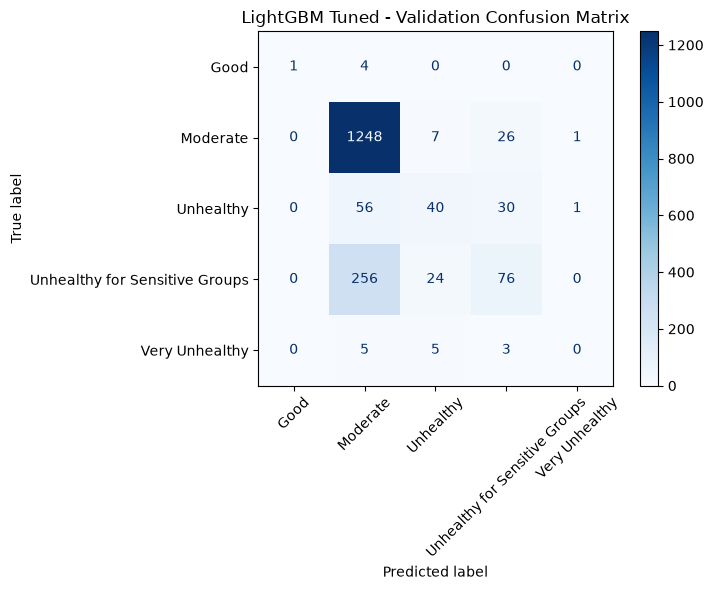

Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\lightgbm_tuned_confusion_matrix.png


In [16]:
# ============================================================
# 15. Generate and Save Tuned Confusion Matrix
# ============================================================

cm_tuned = confusion_matrix(
    y_val,
    y_val_pred_tuned
)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=lgbm_tuned.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

ax.set_title("LightGBM Tuned - Validation Confusion Matrix")
plt.tight_layout()

confusion_matrix_path = (
    pictures_dir / "lightgbm_tuned_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", confusion_matrix_path)

## 16. Baseline vs Tuned Performance Comparison

The validation performance of the baseline and tuned LightGBM models is visualized using Accuracy and Macro F1.

This chart provides a clear visual comparison of the effect of hyperparameter tuning.


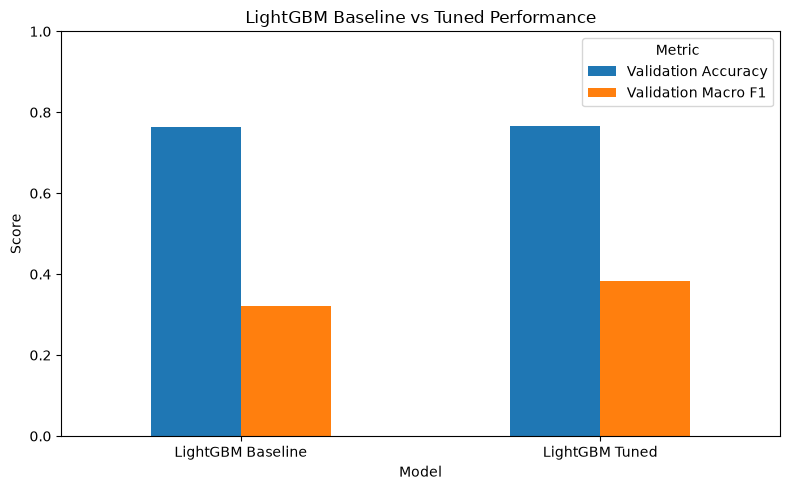

Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\lightgbm_baseline_vs_tuned.png


In [17]:
# ============================================================
# 16. Plot Baseline vs Tuned Performance
# ============================================================

plot_df = comparison_df.set_index("Model")[
    ["Validation Accuracy", "Validation Macro F1"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("LightGBM Baseline vs Tuned Performance")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

comparison_plot_path = (
    pictures_dir / "lightgbm_baseline_vs_tuned.png"
)

plt.savefig(
    comparison_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", comparison_plot_path)

## 17. Save Best Hyperparameters

The selected LightGBM hyperparameters are saved as a CSV file together with the corresponding validation performance.

This provides a reproducible record of the final tuned configuration selected during hyperparameter tuning.


In [18]:
# ============================================================
# 17. Save Best Hyperparameters
# ============================================================

best_parameters_df = pd.DataFrame([{
    **best_params,
    "validation_accuracy": tuned_accuracy,
    "validation_macro_f1": tuned_macro_f1
}])

best_parameters_path = (
    results_dir / "lightgbm_best_parameters.csv"
)

best_parameters_df.to_csv(
    best_parameters_path,
    index=False
)

print("Saved:", best_parameters_path)

display(best_parameters_df)

Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\lightgbm_best_parameters.csv


,n_estimators,learning_rate,num_leaves,max_depth,subsample,colsample_bytree,validation_accuracy,validation_macro_f1
0,200,0.05,31,5,0.8,1.0,0.765564,0.382495


## 18. Save Tuned Model Results

The final validation performance of the tuned LightGBM model is saved as a CSV file.

The saved results include the validation Accuracy and Macro F1 score used to assess the tuned model.


In [19]:
# ============================================================
# 18. Save Tuned Model Results
# ============================================================

tuned_results_df = pd.DataFrame([{
    "Model": "LightGBM Tuned",
    "Validation Accuracy": tuned_accuracy,
    "Validation Macro F1": tuned_macro_f1
}])

tuned_results_path = (
    results_dir / "lightgbm_tuned_results.csv"
)

tuned_results_df.to_csv(
    tuned_results_path,
    index=False
)

print("Saved:", tuned_results_path)

display(tuned_results_df)

Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\lightgbm_tuned_results.csv


,Model,Validation Accuracy,Validation Macro F1
0,LightGBM Tuned,0.765564,0.382495


## 19. Tuned Model Feature Importance

Feature importance is extracted from the tuned LightGBM model to identify the processed features that contributed most to the model's predictions.

The feature importance values are saved for further analysis and visualization.


In [20]:
# ============================================================
# 19. Extract and Save Tuned Feature Importance
# ============================================================

feature_names = preprocessor.get_feature_names_out()

tuned_feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": lgbm_tuned.feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

feature_importance_path = (
    results_dir / "lightgbm_tuned_feature_importance.csv"
)

tuned_feature_importance_df.to_csv(
    feature_importance_path,
    index=False
)

print("Saved:", feature_importance_path)

display(
    tuned_feature_importance_df.head(20)
)

Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\lightgbm_tuned_feature_importance.csv


,feature,importance
0,numeric__year,1266
1,numeric__longitude,1196
2,numeric__latitude,962
3,numeric__max_to_mean_ratio,895
4,numeric__observation_count,863
5,numeric__observation_percent,612
6,numeric__valid_day_count,609
7,numeric__ten_percentile,602
8,numeric__seventy_five_percentile,600
9,numeric__pm25_change_1yr,594


## 20. Visualize Tuned Feature Importance

The 20 most important processed features of the tuned LightGBM model are visualized using a horizontal bar chart.

Visualizing the top features makes it easier to interpret which variables contributed most strongly to the model.


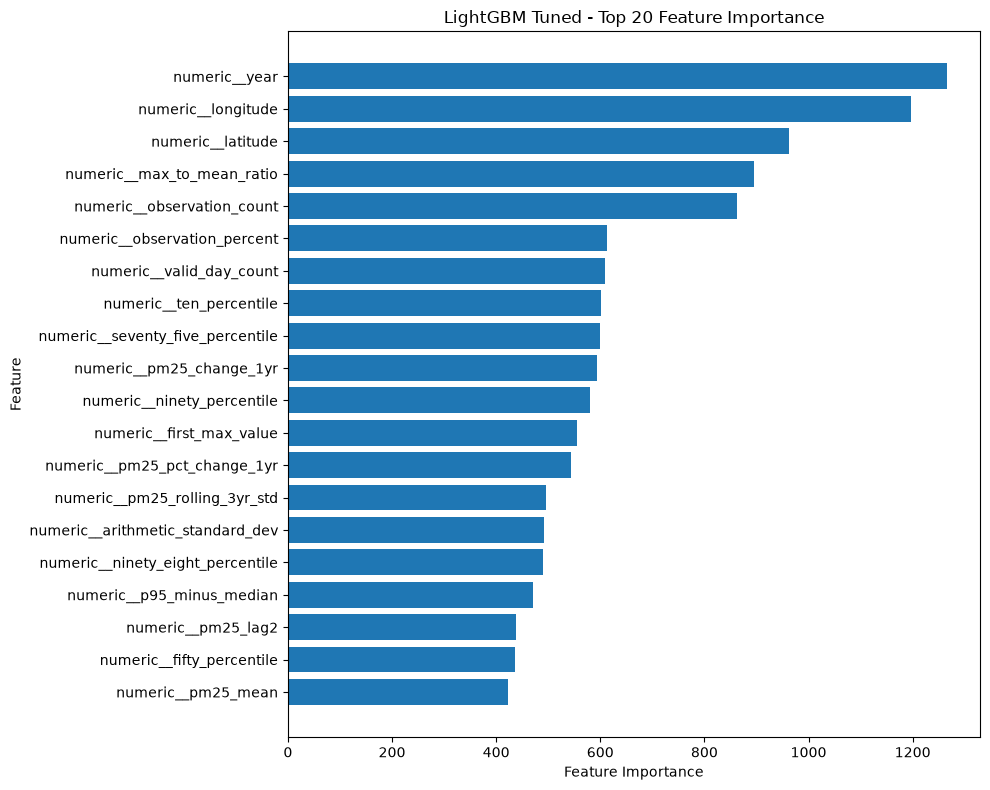

Saved: g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\lightgbm_tuned_feature_importance.png


In [21]:
# ============================================================
# 20. Plot Tuned Feature Importance
# ============================================================

top_features = tuned_feature_importance_df.head(20).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title("LightGBM Tuned - Top 20 Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

tuned_feature_plot_path = (
    pictures_dir / "lightgbm_tuned_feature_importance.png"
)

plt.savefig(
    tuned_feature_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", tuned_feature_plot_path)

## 21. Final Output Check

The generated result files and visualizations are checked to ensure that the LightGBM hyperparameter tuning experiment has been completed successfully.

The test set was not used for hyperparameter selection or model tuning.


In [22]:
# ============================================================
# 21. Final Output Check
# ============================================================

expected_outputs = [
    tuning_results_path,
    comparison_path,
    tuned_report_path,
    best_parameters_path,
    tuned_results_path,
    feature_importance_path,
    confusion_matrix_path,
    comparison_plot_path,
    tuned_feature_plot_path
]

print("LightGBM Tuning Output Check\n")

for path in expected_outputs:
    print(
        ("OK" if path.exists() else "MISSING"),
        "-",
        path
    )

print("\nIMPORTANT: The test set was not used for hyperparameter selection.")

LightGBM Tuning Output Check

OK - g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\lightgbm_tuning_all_results.csv
OK - g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\lightgbm_baseline_vs_tuned.csv
OK - g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\lightgbm_tuned_classification_report.csv
OK - g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\lightgbm_best_parameters.csv
OK - g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\lightgbm_tuned_results.csv
OK - g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\model_results\lightgbm_tuned_feature_importance.csv
OK - g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\lightgbm_tuned_confusion_matrix.png
OK - g:\ACHINI\sliit activities\Y3S2\Data Science\FDM\FDM-Mini-Project\reports\pictures\li

## 22. Final Summary

The LightGBM classifier was systematically tuned using a chronological training and validation setup.

The hyperparameter search evaluated multiple combinations of `n_estimators`, `learning_rate`, `num_leaves`, `max_depth`, `subsample`, and `colsample_bytree`.

The best configuration was selected using validation Macro F1 as the primary metric.

### Best Configuration

* `n_estimators`: 200
* `learning_rate`: 0.05
* `num_leaves`: 31
* `max_depth`: 5
* `subsample`: 0.8
* `colsample_bytree`: 1.0

### Validation Performance

| Metric   | Baseline |    Tuned |
| -------- | -------: | -------: |
| Accuracy | 0.764400 | 0.765564 |
| Macro F1 | 0.320700 | 0.382495 |

The tuned model achieved a higher validation Macro F1 than the baseline model. The improvement in Macro F1 indicates improved overall performance across the imbalanced target classes.

The test dataset was kept untouched during hyperparameter tuning and remains reserved for final model evaluation.
